# Final Training for Bi-LSTM with Data Augmentation and Feature Engineering

This notebook performs final model training on the complete training set. The trained model is evaluated on the held-out test set at multiple granularities (sequence, file, and person levels).

# Configuration and Setup

Setting up the environment for reproducible final model training:
- **Seed Configuration**: Fixed random seed (42) across all libraries (Python, NumPy, TensorFlow)
- **Deterministic Operations**: TensorFlow configured for deterministic GPU operations
- **Channel Selection**: Five key handwriting dynamics features (Fingergrip, Axial Pressure, Tilt X/Y/Z)
- **Environment Variables**: PYTHONHASHSEED and TF_DETERMINISTIC_OPS set for consistency

In [1]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading

Loading preprocessed training and testing datasets with applied augmentation and feature engineering:
- **Training Data**: Complete augmented training set for final model training
- **Testing Data**: Held-out test set never seen during training
- **Data Format**: Pickle files containing windowed sequences with labels and metadata
- **Features Included**: Statistical features, mass calculations, delta values, and temporal patterns

In [2]:
# =====================================
# LOAD THE CLEAN, SPLIT DATA
# =====================================

df_train = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/Without Attention/df_train.pkl')
df_test = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/Without Attention/df_test.pkl')

print("Clean data loaded.")
print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")

Clean data loaded.
Training samples: 32637
Testing samples: 2577


# Model Dependencies

Importing essential libraries for deep learning model construction and evaluation:
- **TensorFlow/Keras**: Neural network architecture (Bi-LSTM, Attention layers)
- **Optimization**: Adam optimizer with learning rate scheduling and regularization
- **Metrics**: Classification reports, confusion matrices, ROC/PR curves, AUC scores
- **Data Splitting**: Train-test split utilities for final evaluation

In [3]:
# =====================================
# IMPORTS FOR MODELING
# =====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split


# Sequence Generation and Normalization

Creating overlapping temporal sequences from windowed data for LSTM processing:
- **Sequence Length**: 20 consecutive windows per sequence
- **Step Size**: 10 windows overlap to capture temporal continuity
- **Feature Selection**: Excluding metadata columns (label, file_name, Person_ID, demographics)
- **Standardization**: StandardScaler fitted on training data and applied to both train and test sets
- **Output Shape**: (n_sequences, 20, n_features) for Bi-LSTM input

In [4]:
# =====================================
# CREATE SEQUENCES OF WINDOWS
# =====================================

def create_sequences(df, feature_cols, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    grouped = df.groupby('file_name')
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for file_name, group in tqdm(grouped):
        features = group[feature_cols].values
        if len(features) < sequence_length:
            continue
        label = group['label'].iloc[0]
        person_id = group['Person_ID_Number'].iloc[0]
        for i in range(0, len(features) - sequence_length + 1, step_size):
            sequence = features[i : i + sequence_length]
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

# Define non-feature columns in delta DataFrame
base_non_feature_cols = ['label', 'file_name', 'start_index', 'end_index', 'Person_ID_Number',
                        'Age', 'Gender', 'Writing_Hand', 'augmented', 'original_duration', 'target_duration']

# Determine feature columns: include stats, mass, delta_... etc.
feature_cols = [col for col in df_train.columns if col not in base_non_feature_cols]
feature_cols = [col for col in feature_cols if np.issubdtype(df_train[col].dtype, np.number)]

SEQUENCE_LENGTH = 20
STEP_SIZE = 10

X_train_seq, y_train_seq, sequence_file_names_train, sequence_person_ids_train = create_sequences(df_train, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
X_test_seq, y_test_seq, sequence_file_names_test, sequence_person_ids_test = create_sequences(df_test, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)

print("\n--- Data Shapes After Sequencing ---")
print(f"X_train sequences shape: {X_train_seq.shape}")
print(f"y_train sequences shape: {y_train_seq.shape}")
print(f"X_test sequences shape: {X_test_seq.shape}")

n_features = X_train_seq.shape[2]
X_train_reshaped_for_scaling = X_train_seq.reshape(-1, n_features)
X_test_reshaped_for_scaling = X_test_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_reshaped_for_scaling)
X_test_scaled_flat = scaler.transform(X_test_reshaped_for_scaling)

X_train_final = X_train_scaled_flat.reshape(X_train_seq.shape)
X_test_final = X_test_scaled_flat.reshape(X_test_seq.shape)

print("\n--- Final Data Shapes for LSTM Model ---")
print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test_final.shape}")

Creating sequences of length 20 with step 10...


100%|██████████| 445/445 [00:01<00:00, 416.67it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 509.60it/s]


--- Data Shapes After Sequencing ---
X_train sequences shape: (2623, 20, 150)
y_train sequences shape: (2623,)
X_test sequences shape: (139, 20, 150)



--- Final Data Shapes for LSTM Model ---
Final X_train shape: (2623, 20, 150)
Final X_test shape: (139, 20, 150)


# Model Architecture: Bi-LSTM

Building a deep learning model that combines bidirectional temporal processing:
- **Bi-LSTM Layer**: 64 units capturing forward and backward temporal dependencies
- **Regularization**: L2 regularization (0.0001) and Dropout (0.4) to prevent overfitting
- **Dense Layer**: 16-unit fully connected layer with ReLU activation
- **Output**: Sigmoid activation for binary classification (Parkinson's vs. Control)
- **Optimization**: Adam optimizer with binary cross-entropy loss

In [5]:
# =====================================
# MODEL: BiLSTM
# =====================================

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(64, return_sequences=False, kernel_regularizer=l2(0.0001))
    )(inputs)
    x = Dropout(0.4)(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# Final Model Training

Training the final model on the complete training dataset:
- **Training Epochs**: 13 epochs (determined from cross-validation early stopping patterns of Attention-Based Bi-LSTM with Aug and FE)
- **Batch Size**: 64 samples per batch
- **No Validation Split**: Using all training data to maximize model learning
- **Learning Curves**: Monitoring training accuracy and loss progression
- **Purpose**: Create production-ready model for deployment and final test evaluation


Training final model...
Epoch 1/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5829 - loss: 0.7220
Epoch 2/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7030 - loss: 0.6292
Epoch 3/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7442 - loss: 0.5709
Epoch 4/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7766 - loss: 0.5336
Epoch 5/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8018 - loss: 0.4981
Epoch 6/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8231 - loss: 0.4654
Epoch 7/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8342 - loss: 0.4326
Epoch 8/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8555 - loss: 0.4018
Epoch 9/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8719 - loss: 0.3753
Epoch 10/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8902 - loss: 0.3453
Epoch 11/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8990 - loss: 0.3146
Epoch 12/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/ste

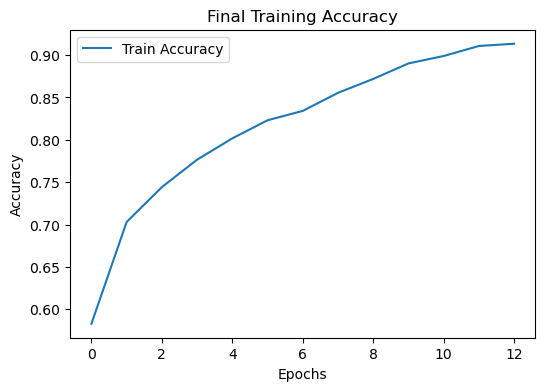

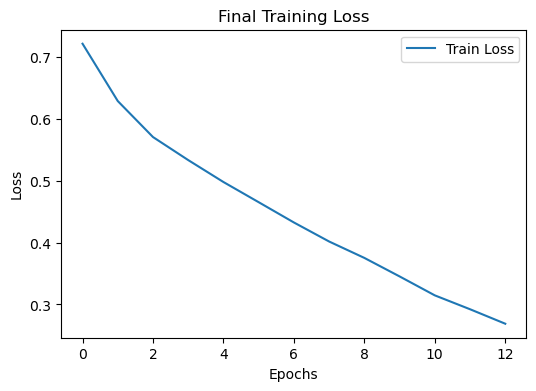

In [6]:
# =====================================
# FINAL TRAINING
# =====================================

final_model = create_bilstm_model(input_shape=(X_train_final.shape[1], X_train_final.shape[2]))

final_epochs = 13

print(f"\nTraining final model...")
history_final = final_model.fit(
    X_train_final, y_train_seq,
    epochs=final_epochs,
    batch_size=64,
    verbose=1
)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.title('Final Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.title('Final Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sequence-Level Evaluation

Evaluating model performance at the individual sequence level (finest granularity):
- **Predictions**: Binary classification for each 20-window sequence
- **Metrics**: Accuracy, precision, recall, F1-score for both classes
- **Confusion Matrix**: True positive/negative vs predicted classifications
- **ROC Curve**: True positive rate vs false positive rate with AUC score
- **Precision-Recall Curve**: Precision vs recall trade-off with average precision
- **Use Case**: Understanding model performance on individual temporal windows

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step

Sequence-level Accuracy: 0.8849


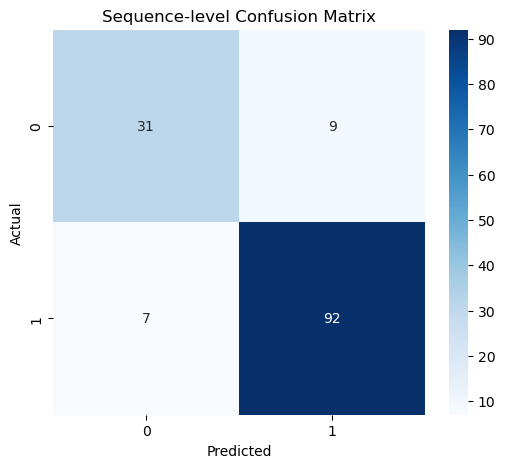


Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.8158    0.7750    0.7949        40
           1     0.9109    0.9293    0.9200        99

    accuracy                         0.8849       139
   macro avg     0.8633    0.8521    0.8574       139
weighted avg     0.8835    0.8849    0.8840       139



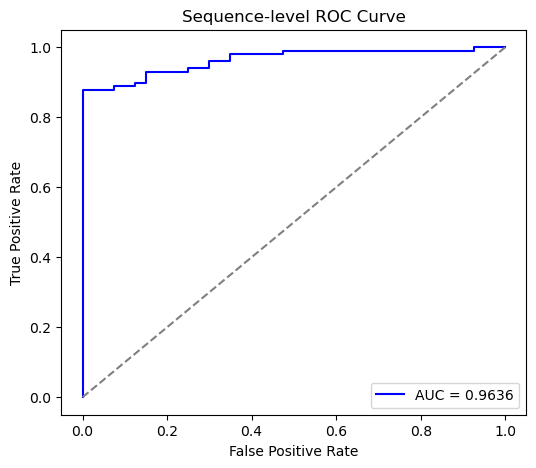

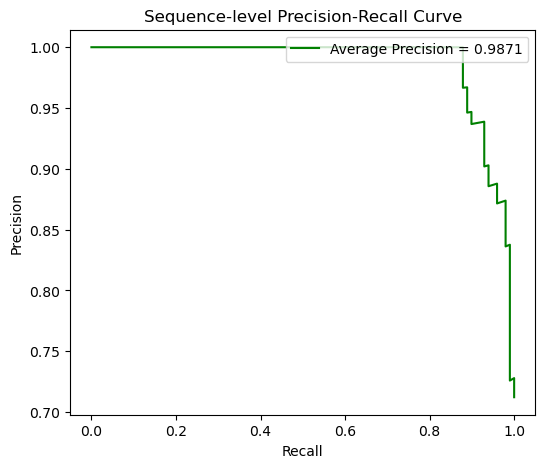

In [7]:
# =====================================
# EVALUATE (SEQUENCE-LEVEL)
# =====================================

# Predict
y_test_pred_prob = final_model.predict(X_test_final)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).flatten()

# Accuracy 
overall_accuracy = accuracy_score(y_test_seq, y_test_pred)
print(f"\nSequence-level Accuracy: {overall_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sequence-level Confusion Matrix")
plt.show()

# Classification Report
print("\nSequence-level Classification Report:")
print(classification_report(y_test_seq, y_test_pred, digits=4))

# ROC Curve AND AUC
fpr, tpr, thresholds = roc_curve(y_test_seq, y_test_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sequence-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curves
precision, recall, thresholds_pr = precision_recall_curve(y_test_seq, y_test_pred_prob)
avg_precision = average_precision_score(y_test_seq, y_test_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Sequence-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# File-Level Evaluation

Aggregating predictions to the file level (one handwriting sample per person):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same file
- **Threshold**: 0.5 probability cutoff for binary classification
- **Clinical Relevance**: Each file represents one complete handwriting task
- **Metrics**: Same comprehensive metrics as sequence-level (accuracy, AUC, precision, recall, F1)
- **Use Case**: More stable predictions by combining multiple temporal observations


File-level Accuracy: 0.7414


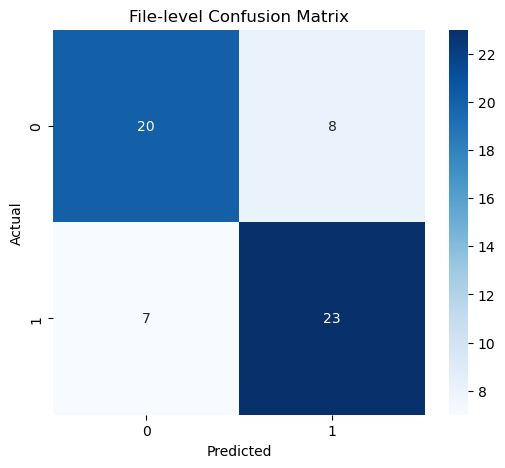


File-level Classification Report:
              precision    recall  f1-score   support

           0     0.7407    0.7143    0.7273        28
           1     0.7419    0.7667    0.7541        30

    accuracy                         0.7414        58
   macro avg     0.7413    0.7405    0.7407        58
weighted avg     0.7414    0.7414    0.7411        58



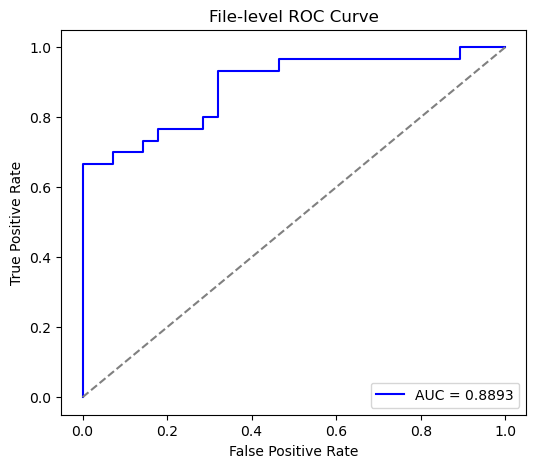

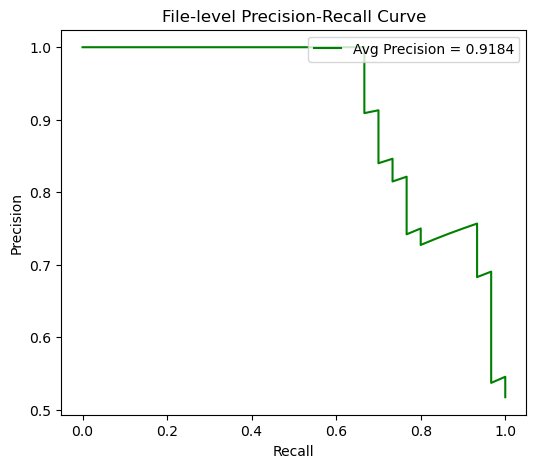

In [8]:
# =====================================
# EVALUATE (FILE-LEVEL)
# =====================================

# Aggregate per file
df_pred = pd.DataFrame({
    "file_name": sequence_file_names_test,
    "true_label": y_test_seq,
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
file_level_prob = df_pred.groupby("file_name")["pred_prob"].mean()
file_level_pred = (file_level_prob >= 0.5).astype(int)

# Get true label
file_level_true = df_pred.groupby("file_name")["true_label"].first()

# Accuracy
file_accuracy = accuracy_score(file_level_true, file_level_pred)
print(f"\nFile-level Accuracy: {file_accuracy:.4f}")

# Confusion Matrix
cm_file = confusion_matrix(file_level_true, file_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_file, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("File-level Confusion Matrix")
plt.show()

# Classification Report
print("\nFile-level Classification Report:")
print(classification_report(file_level_true, file_level_pred, digits=4))

# ROC Curve & AUC
fpr_file, tpr_file, _ = roc_curve(file_level_true, file_level_prob)
roc_auc_file = auc(fpr_file, tpr_file)

plt.figure(figsize=(6,5))
plt.plot(fpr_file, tpr_file, color='blue', label=f"AUC = {roc_auc_file:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("File-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_file, recall_file, _ = precision_recall_curve(file_level_true, file_level_prob)
avg_precision_file = average_precision_score(file_level_true, file_level_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_file, precision_file, color='green', label=f"Avg Precision = {avg_precision_file:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("File-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Person-Level Evaluation

Aggregating predictions to the person level (highest clinical relevance):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same person
- **Threshold**: 0.5 probability cutoff for final diagnosis
- **Clinical Application**: Most relevant for real-world screening scenarios
- **Robustness**: Multiple observations per person reduce noise and outlier effects
- **Metrics**: Same comprehensive evaluation metrics
- **Use Case**: Final diagnostic decision for each individual patient/control


Person-level Accuracy: 0.7778


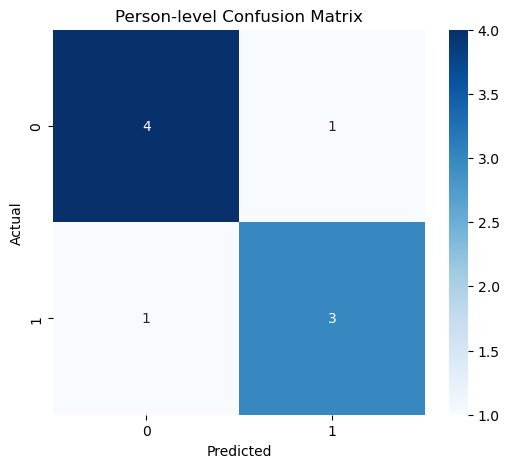


Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.8000    0.8000         5
           1     0.7500    0.7500    0.7500         4

    accuracy                         0.7778         9
   macro avg     0.7750    0.7750    0.7750         9
weighted avg     0.7778    0.7778    0.7778         9



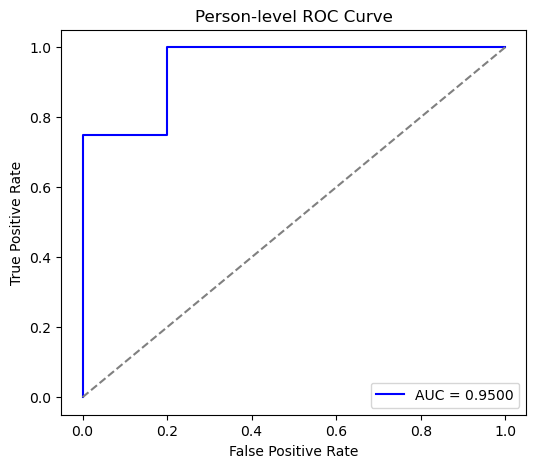

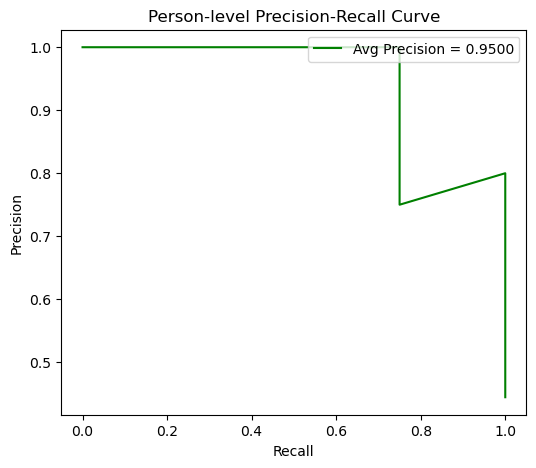

In [9]:
# =====================================
# EVALUATE (PERSON-LEVEL)
# =====================================

# Aggregate per person
df_pred_person = pd.DataFrame({
    "person_id": sequence_person_ids_test,
    "true_label": y_test_seq,   
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
person_level_prob = df_pred_person.groupby("person_id")["pred_prob"].mean()
person_level_pred = (person_level_prob >= 0.5).astype(int)

# Get true label
person_level_true = df_pred_person.groupby("person_id")["true_label"].first()

# Accuracy
person_accuracy = accuracy_score(person_level_true, person_level_pred)
print(f"\nPerson-level Accuracy: {person_accuracy:.4f}")

# Confusion Matrix
cm_person = confusion_matrix(person_level_true, person_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_person, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Person-level Confusion Matrix")
plt.show()

# Classification Report
print("\nPerson-level Classification Report:")
print(classification_report(person_level_true, person_level_pred, digits=4))

# ROC Curve & AUC
fpr_person, tpr_person, _ = roc_curve(person_level_true, person_level_prob)
roc_auc_person = auc(fpr_person, tpr_person)
plt.figure(figsize=(6,5))
plt.plot(fpr_person, tpr_person, color='blue', label=f"AUC = {roc_auc_person:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Person-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_person, recall_person, _ = precision_recall_curve(person_level_true, person_level_prob)
avg_precision_person = average_precision_score(person_level_true, person_level_prob)
plt.figure(figsize=(6,5))
plt.plot(recall_person, precision_person, color='green', label=f"Avg Precision = {avg_precision_person:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Person-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Multi-Level Performance Comparison

Comprehensive comparison of model performance across all three evaluation granularities:
- **Sequence Level**: Individual predictions on 20-window sequences
- **File Level**: Aggregated predictions per handwriting sample
- **Person Level**: Aggregated predictions per participant
- **Comparison Metrics**: Accuracy, AUC, precision, recall, and F1-score for both classes
- **Expected Pattern**: Performance typically improves with aggregation due to noise reduction
- **Clinical Insight**: Person-level metrics most relevant for diagnostic utility

In [10]:
# =====================================
# COMPARISON TABLE
# =====================================

# Sequence-level metrics
seq_accuracy = overall_accuracy
seq_auc = roc_auc
seq_report = classification_report(y_test_seq, y_test_pred, output_dict=True)

seq_prec_0 = seq_report['0']['precision']
seq_rec_0 = seq_report['0']['recall']
seq_f1_0 = seq_report['0']['f1-score']
seq_prec_1 = seq_report['1']['precision']
seq_rec_1 = seq_report['1']['recall']
seq_f1_1 = seq_report['1']['f1-score']

# File-level metrics
file_acc = file_accuracy
file_auc = roc_auc_file
file_report = classification_report(file_level_true, file_level_pred, output_dict=True)

file_prec_0 = file_report['0']['precision']
file_rec_0 = file_report['0']['recall']
file_f1_0 = file_report['0']['f1-score']
file_prec_1 = file_report['1']['precision']
file_rec_1 = file_report['1']['recall']
file_f1_1 = file_report['1']['f1-score']

# Person-level metrics
person_acc = person_accuracy
person_auc = roc_auc_person
person_report = classification_report(person_level_true, person_level_pred, output_dict=True)

person_prec_0 = person_report['0']['precision']
person_rec_0 = person_report['0']['recall']
person_f1_0 = person_report['0']['f1-score']
person_prec_1 = person_report['1']['precision']
person_rec_1 = person_report['1']['recall']
person_f1_1 = person_report['1']['f1-score']


final_results_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "AUC",
        "Precision (Class 0)", "Recall (Class 0)", "F1 (Class 0)",
        "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)"
    ],
    "Sequence Level": [
        f"{seq_accuracy:.4f}", f"{seq_auc:.4f}",
        f"{seq_prec_0:.4f}", f"{seq_rec_0:.4f}", f"{seq_f1_0:.4f}",
        f"{seq_prec_1:.4f}", f"{seq_rec_1:.4f}", f"{seq_f1_1:.4f}"
    ],
    "File Level": [
        f"{file_acc:.4f}", f"{file_auc:.4f}",
        f"{file_prec_0:.4f}", f"{file_rec_0:.4f}", f"{file_f1_0:.4f}",
        f"{file_prec_1:.4f}", f"{file_rec_1:.4f}", f"{file_f1_1:.4f}"
    ],
    "Person Level": [
        f"{person_acc:.4f}", f"{person_auc:.4f}",
        f"{person_prec_0:.4f}", f"{person_rec_0:.4f}", f"{person_f1_0:.4f}",
        f"{person_prec_1:.4f}", f"{person_rec_1:.4f}", f"{person_f1_1:.4f}"
    ]
})

print("\nFinal Performance Comparison: Sequence vs File vs Person Level")
display(final_results_table)


Final Performance Comparison: Sequence vs File vs Person Level


,Metric,Sequence Level,File Level,Person Level
0,Accuracy,0.8849,0.7414,0.7778
1,AUC,0.9636,0.8893,0.9500
2,Precision (Class 0),0.8158,0.7407,0.8000
3,Recall (Class 0),0.7750,0.7143,0.8000
4,F1 (Class 0),0.7949,0.7273,0.8000
5,Precision (Class 1),0.9109,0.7419,0.7500
6,Recall (Class 1),0.9293,0.7667,0.7500
7,F1 (Class 1),0.9200,0.7541,0.7500
